In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score, recall_score,f1_score,roc_curve, roc_auc_score, ConfusionMatrixDisplay, make_scorer
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, GridSearchCV
import time

In [7]:
diabetes_train = pd.read_csv("datasets/diabetes_train.csv")
diabetes_test = pd.read_csv("datasets/diabetes_test.csv")

In [ ]:
def cross_validate_model(model, X, y, cv, bivariate = True, print_results = True):
    """Perform cross-validation and print metrics if asked"""
    if bivariate == False:
        scoring = {
            'accuracy': 'accuracy',
            'precision': make_scorer(precision_score, average='weighted', zero_division=1),
            'recall': make_scorer(recall_score, average='weighted', zero_division=1),
            'f1': make_scorer(f1_score, average='weighted', zero_division=1)
        }
        start = time.time()
        results = cross_validate(model, X, y, cv=cv, scoring=scoring)
        end = time.time()
        if print_results == True:
            print(f"Accuracy: {results['test_accuracy'].mean():.4f}")
            print(f"Precision: {results['test_precision'].mean():.4f}")
            print(f"Recall: {results['test_recall'].mean():.4f}")
            print(f"F1 Score: {results['test_f1'].mean():.4f}")
            print("Prediction time: ", end-start)
        return results
    else:
        scoring = ['accuracy', 'precision', 'recall', 'f1']
        start = time.time()
        cv_results = cross_validate(model, X, y, cv=cv, scoring=scoring)
        end = time.time()
        if print_results == True:
            print(f"Accuracy: {cv_results['test_accuracy'].mean():.4f}")
            print(f"Precision: {cv_results['test_precision'].mean():.4f}")
            print(f"Recall: {cv_results['test_recall'].mean():.4f}")
            print(f"F1 Score: {cv_results['test_f1'].mean():.4f}")
            print("Time:", end - start)
        return cv_results

In [57]:
def hyperparameterTuning(X, y, cv, bivariate):
    param_grid = {
    'C':  [0.01, 0.1, 1, 10, 100],
    'l1_ratio': [0],
    'solver': ['lbfgs','liblinear', 'saga']
    }

    if bivariate == True:
        scoring = {
        'accuracy': 'accuracy',
        'precision_weighted': make_scorer(precision_score, average='macro', zero_division=1),
        'recall_weighted': make_scorer(recall_score, average='macro', zero_division=1),
        'f1_weighted': make_scorer(f1_score, average='macro', zero_division=1)
        }

        start = time.time()
        lr = LogisticRegression()
        grid_search = GridSearchCV(lr, param_grid, cv=cv, scoring=scoring, refit='accuracy', n_jobs=-1)
        grid_search.fit(X, y)
        print(f"Best parameters: {grid_search.best_params_}")
        print(f"Best cross-validation accuracy: {grid_search.cv_results_['mean_test_accuracy'][grid_search.best_index_]:.4f}")
        print(f"Best cross-validation precision: {grid_search.cv_results_['mean_test_precision_weighted'][grid_search.best_index_]:.4f}")
        print(f"Best cross-validation recall: {grid_search.cv_results_['mean_test_recall_weighted'][grid_search.best_index_]:.4f}")
        print(f"Best cross-validation F1 Score: {grid_search.cv_results_['mean_test_f1_weighted'][grid_search.best_index_]:.4f}")
        print("Time for Hypertuning: ", time.time()-start)
    else:
        scoring = {
        'accuracy': 'accuracy',
        'precision_weighted': make_scorer(precision_score, average='weighted', zero_division=1),
        'recall_weighted': make_scorer(recall_score, average='weighted', zero_division=1),
        'f1_weighted': make_scorer(f1_score, average='weighted', zero_division=1)
        }
        start = time.time()
        lr = LogisticRegression()
        grid_search = GridSearchCV(lr, param_grid, cv=cv, scoring=scoring, refit='accuracy', n_jobs=-1)
        grid_search.fit(X, y)
        print(f"Best parameters: {grid_search.best_params_}")
        print(f"Best cross-validation accuracy: {grid_search.cv_results_['mean_test_accuracy'][grid_search.best_index_]:.4f}")
        print(f"Best cross-validation precision: {grid_search.cv_results_['mean_test_precision_weighted'][grid_search.best_index_]:.4f}")
        print(f"Best cross-validation recall: {grid_search.cv_results_['mean_test_recall_weighted'][grid_search.best_index_]:.4f}")
        print(f"Best cross-validation F1 Score: {grid_search.cv_results_['mean_test_f1_weighted'][grid_search.best_index_]:.4f}")
        print("Time for Hypertuning: ", time.time()-start)

    best_model = grid_search.best_estimator_  # Best trained model
    best_params = grid_search.best_params_    # Best hyperparameters
    return best_model, best_params 


----------------------------------------------------------------------------------------------
-------------------------------------- ORIGINAL DATASET --------------------------------------
----------------------------------------------------------------------------------------------

In [10]:
X_train = diabetes_train.drop('Outcome', axis = 1)
X_test = diabetes_test.drop('Outcome', axis = 1)
y_train = diabetes_train['Outcome']
y_test = diabetes_test['Outcome']

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

In [33]:
#Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None
model = LogisticRegression(
    C=1,
    l1_ratio=0,
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)
model.fit(X_train_sc, y_train)
y_pred = model.predict(X_test_sc)

          Predicted 0  Predicted 1
Actual 0           83           16
Actual 1           20           35


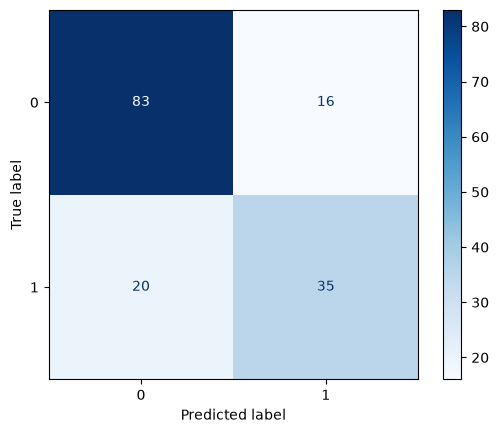

Accuracy: 0.7662337662337663
Precision: 0.6363636363636364
Recall: 0.6862745098039216
F1: 0.660377358490566
AUC: 0.746049876261184


In [38]:
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)
print(cm_df)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.show()
print("Accuracy:", accuracy_score(y_pred, y_test))
print("Precision:", precision_score(y_pred, y_test))
print("Recall:", recall_score(y_pred, y_test))
print("F1:", f1_score(y_pred, y_test))
print("AUC:", roc_auc_score(y_pred, y_test))


In [55]:
cross_validate_model(model, X_train_sc, y_train, cv=10, bivariate = True)

Accuracy: 0.7671
Precision: 0.7101
Recall: 0.5675
F1 Score: 0.6284
Time: 0.4418525695800781


{'fit_time': array([0.00932312, 0.01218295, 0.01103568, 0.01709366, 0.01425505,
        0.00855517, 0.01297307, 0.00701213, 0.0056994 , 0.00403118]),
 'score_time': array([0.02507114, 0.0302372 , 0.03635859, 0.02489829, 0.05633354,
        0.05110168, 0.03184414, 0.01758647, 0.02115178, 0.02138138]),
 'test_accuracy': array([0.70967742, 0.75806452, 0.85483871, 0.77419355, 0.73770492,
        0.78688525, 0.78688525, 0.72131148, 0.78688525, 0.75409836]),
 'test_precision': array([0.57894737, 0.68421053, 0.88235294, 0.75      , 0.64705882,
        0.7       , 0.78571429, 0.6       , 0.78571429, 0.6875    ]),
 'test_recall': array([0.52380952, 0.59090909, 0.68181818, 0.54545455, 0.52380952,
        0.66666667, 0.52380952, 0.57142857, 0.52380952, 0.52380952]),
 'test_f1': array([0.55      , 0.63414634, 0.76923077, 0.63157895, 0.57894737,
        0.68292683, 0.62857143, 0.58536585, 0.62857143, 0.59459459])}

In [58]:
best_model, best_params = hyperparameterTuning(X_train_sc, y_train, cv=5, bivariate = True)

Best parameters: {'C': 0.1, 'l1_ratio': 0, 'solver': 'liblinear'}
Best cross-validation accuracy: 0.7671
Best cross-validation precision: 0.7495
Best cross-validation recall: 0.7216
Best cross-validation F1 Score: 0.7306
Time for Hypertuning:  0.5061039924621582


----------------------------------------------------------------------------------------------
-------------------------------------- INPUT PERTUBATION -------------------------------------
----------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------
------------------------------------- OUTPUT PERTUBATION -------------------------------------
----------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------
------------------------------------ INTERNAL PERTUBATION ------------------------------------
----------------------------------------------------------------------------------------------